In [43]:
from jetset.jet_model import Jet

jet = Jet(name='test_corona_component', emitters_distribution='bkn',beaming_expr='bulk_theta',verbose=False)

jet.add_EC_component(['EC_Corona','Disk'],disk_type='MultiBB')

jet.parameters.N.val = 1E3
jet.parameters.gmax.val = 5E3
jet.parameters.gamma_break.val = 1000


jet.parameters.B.val = 1
jet.parameters.L_Disk.val = 1E46
jet.make_conical_jet()
jet.parameters.R_H.val = 7E17



adding par: R_H to  R
adding par: theta_open to  R
==> par R is depending on ['R_H', 'theta_open'] according to expr:   R =
np.tan(np.radians(theta_open))*R_H
setting R_H to 5.715026151380672e+16


In the case of the Corona can be useful to define the radius `R_Corona`, the distance from the BH, `R_H_Corona`, and the luminosity as a function of `R_g` and of the disk luminosity. 

In [44]:

#The Corona luminosity will scale as the disk luminosity according to 'L_Disk*L_DC_ratio'
jet.add_user_par('L_DC_ratio',val=1,val_min=0,val_max=100)
jet.make_dependent_par('L_Corona',depends_on=['L_DC_ratio','L_Disk'],par_expr='L_Disk*L_DC_ratio')
jet.parameters.L_DC_ratio.val = .8


jet.add_user_par('R_H_Corona_ratio',val=1,val_min=1,val_max=100)
jet.add_user_par('R_Corona_ratio',val=1,val_min=1,val_max=100)
jet.add_user_par('R_g',val=1E13,val_min=1,val_max=1E20)

def eval_R_g(M_BH):
    from astropy.constants import M_sun,c,G
    return M_BH*(G.cgs.value*M_sun.cgs.value/(c.cgs.value**2))

#R_g will de determined by the actual physical relation R_g=2*M_BH/c**2
jet.make_dependent_par('R_g',depends_on=['M_BH'],par_expr=eval_R_g)

def eval_R_H_corona(R_g,R_H_Corona_ratio):
    return R_H_Corona_ratio*R_g

#The distance of the Corona from the BH will scale as R_g, according to R_H_Corona_ratio*R_g
jet.make_dependent_par('R_H_Corona',depends_on=['R_g','R_H_Corona_ratio'],par_expr="R_H_Corona_ratio*R_g")


def eval_R_corona(R_g,R_Corona_ratio):
    return R_Corona_ratio*R_g

#The radius of the Corona from the BH will scale as R_g, according to R_Corona_ratio*R_g
jet.make_dependent_par('R_Corona',depends_on=['R_g','R_Corona_ratio'],par_expr="R_Corona_ratio*R_g")



adding par: L_DC_ratio to  L_Corona
adding par: L_Disk to  L_Corona
==> par L_Corona is depending on ['L_DC_ratio', 'L_Disk'] according to expr:   L_Corona =
L_Disk*L_DC_ratio
adding par: M_BH to  R_g
==> par R_g is depending on ['M_BH'] according to expr:   R_g =
def eval_R_g(M_BH):
    from astropy.constants import M_sun,c,G
    return M_BH*(G.cgs.value*M_sun.cgs.value/(c.cgs.value**2))

adding par: R_g to  R_H_Corona
adding par: R_H_Corona_ratio to  R_H_Corona
==> par R_H_Corona is depending on ['R_g', 'R_H_Corona_ratio'] according to expr:   R_H_Corona =
R_H_Corona_ratio*R_g
adding par: R_g to  R_Corona
adding par: R_Corona_ratio to  R_Corona
==> par R_Corona is depending on ['R_g', 'R_Corona_ratio'] according to expr:   R_Corona =
R_Corona_ratio*R_g


In [45]:

jet.parameters.R_H_Corona_ratio.val=10
jet.parameters.R_Corona_ratio.val=20

In [46]:
'%e'%eval_R_g(1E9)

'1.476625e+14'

We can set the spectral parameters of the Corona

In [47]:
jet.parameters.alpha_Corona.val_min=-2
jet.parameters.alpha_Corona.val = 1
jet.parameters.nu_cut_Corona.val = 1.5E18
jet.parameters.nu_cut_low_Corona.val = 1E15

In [48]:
jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
test_corona_component,"*R(D,theta_open)",region_size,cm,6.124206e+16,1.000000e+03,1.000000e+30,False,True
test_corona_component,R_H(M),region_position,cm,7.000000e+17,0.000000e+00,--,False,False
test_corona_component,B,magnetic_field,gauss,1.000000e+00,0.000000e+00,--,False,False
test_corona_component,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
test_corona_component,theta,jet-viewing-angle,deg,1.000000e-01,0.000000e+00,9.000000e+01,False,False
test_corona_component,BulkFactor,jet-bulk-factor,lorentz-factor*,1.000000e+01,1.000000e+00,1.000000e+05,False,False
test_corona_component,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,False
test_corona_component,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
test_corona_component,gmax,high-energy-cut-off,lorentz-factor*,5.000000e+03,1.000000e+00,1.000000e+15,False,False
test_corona_component,N,emitters_density,1 / cm3,1.000000e+03,0.000000e+00,--,False,False


None

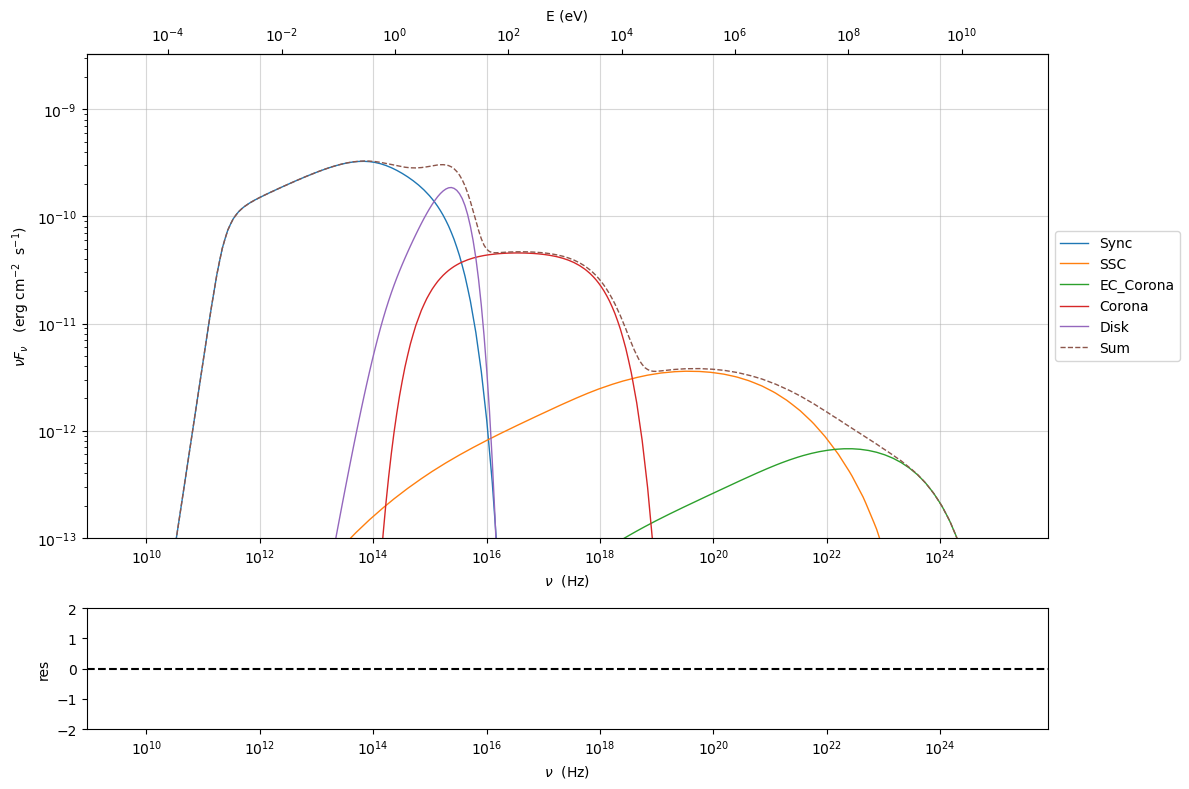

In [50]:
jet.eval()
p=jet.plot_model()
p.setlim(y_min=1E-13)